# Segmentación de Operaciones de Exportación mediante Clustering
### Comercio exterior — Chile

**Objetivo del proyecto:** identificar segmentos naturales dentro de las operaciones de exportación registradas, a partir de variables de magnitud (monto, peso, ticket promedio) y frecuencia de operación, para caracterizar distintos perfiles de comercio exterior.

**Enfoque:** idéntico al aplicado sobre el dataset de importación, para mantener comparabilidad entre ambos análisis:
1. Preprocesamiento de variables numéricas (corrección de sesgo) y categóricas (codificación).
2. Selección del número de clusters (k) mediante Silhouette Score y método del codo.
3. Modelado con **K-Means** (`MiniBatchKMeans`), evaluando dos configuraciones: una línea base conservadora (k=2) y una versión de mayor granularidad (k=5).
4. Validación cruzada de la estabilidad del modelo.
5. Contraste con **K-Prototypes**, algoritmo diseñado para datos mixtos (numéricos + categóricos), como validación independiente del resultado.
6. Caracterización de negocio de los clusters resultantes.

**Dataset:** ~428.000 operaciones de exportación, con variables de monto, cantidad, peso, rubro de la empresa, país de destino y vía de transporte.

> Este notebook replica la estructura del análisis de importación para permitir una comparación directa entre ambos flujos de comercio exterior.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans# son muchos datos así que usaré este
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import silhouette_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga de datos

In [ ]:
df_export = pd.read_csv("./Data/Processed/processed_datos_chile_export.csv")

## 2. Selección de variables

Se excluyen `empresa` (alta cardinalidad) y `descripcion_arancel` (texto libre) del modelado, por las mismas razones aplicadas en el análisis de importación. Se conservan en el dataset para el análisis de caracterización posterior.

In [ ]:
categorical_cols = ['rubro_empresa', 'pais', 'via_transporte']

In [ ]:
numeric_cols = ['total_operacion',
 'cantidad_operacion',
 'ticket_promedio',
 'peso_total']

## 3. Preprocesamiento

- **Variables numéricas:** al igual que en import, el monto y el peso presentan una distribución fuertemente sesgada. Se aplica `log1p` antes de estandarizar.
- **Variables categóricas:** codificación con `OneHotEncoder`, ignorando categorías no vistas en entrenamiento.

In [ ]:
log_pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scale", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            log_pipeline,
            numeric_cols
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_cols
        )
    ]
)

## 4. Pipeline de modelado

Se utiliza `MiniBatchKMeans` por las mismas razones de escalabilidad que en import, aunque aquí el volumen de datos es considerablemente menor (~428K filas vs. ~1,57M).

In [ ]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("kmeans", MiniBatchKMeans(
        n_clusters=5,
        batch_size=1024,
        n_init=10,
        max_iter=100,
        random_state=42
    ))
])

## 5. Selección del número de clusters (k)

### 5.1 Silhouette Score

In [1]:
k_values = range(2, 6)

silhouette_scores = []

X = df_export[numeric_cols + categorical_cols]

X_transformed = preprocessor.fit_transform(X)

for k in k_values:

    pipeline.set_params(
        kmeans__n_clusters=k
    )

    labels = pipeline.named_steps["kmeans"].fit_predict(
        X_transformed
    )

    score = silhouette_score(
        X_transformed,
        labels,
        sample_size=5000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(f"k={k}: silhouette={score:.4f}")

k=2: silhouette=0.2661
k=3: silhouette=0.2004
k=4: silhouette=0.1414
k=5: silhouette=0.1424


### 5.2 Método del codo (inercia)

In [2]:
k_values = range(2, 6)

inertia_scores = []

X = df_export[numeric_cols + categorical_cols]

X_transformed = preprocessor.fit_transform(X)

for k in k_values:

    pipeline.set_params(
        kmeans__n_clusters=k
    )

    pipeline.named_steps["kmeans"].fit(
        X_transformed
    )

    score = pipeline.named_steps["kmeans"].inertia_

    inertia_scores.append(score)

    print(f"k={k}: inertia={score:.2f}")

k=2: inertia=1937070.75
k=3: inertia=1649581.10
k=4: inertia=1514179.67
k=5: inertia=1422773.66


### 5.3 Visualización

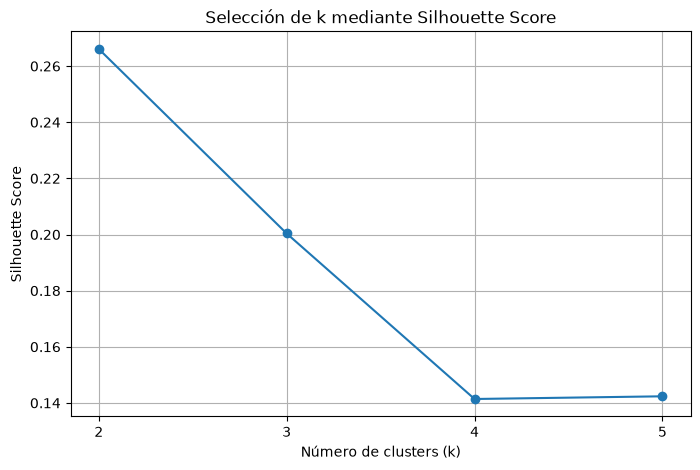

In [3]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Selección de k mediante Silhouette Score")
plt.xticks(k_values)
plt.grid(True)

plt.show()

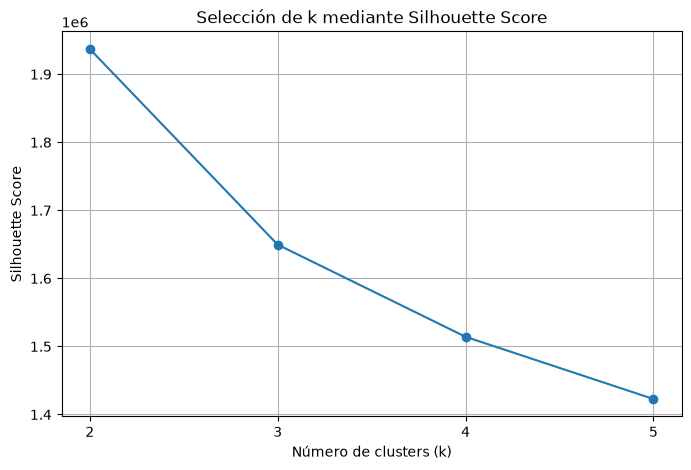

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_scores,
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Selección de k mediante Silhouette Score")
plt.xticks(k_values)
plt.grid(True)

plt.show()

### 5.4 Interpretación

El silhouette score es más alto en **k=2 (0,2661)** y decrece de forma consistente en el resto del rango evaluado (k=3 a k=5). La inercia decrece de forma continua sin un quiebre claro, por lo que no aporta una señal decisiva adicional.

> **Nota metodológica:** a diferencia del notebook de importación (que evaluó k=2 a k=9), aquí el barrido se limitó a k=2–5. Sería recomendable, como trabajo futuro, extender el rango para confirmar que no existe un óptimo local más allá de k=5.

Igual que en import, k=2 es la opción mejor soportada estadísticamente, pero una segmentación binaria tiene poco valor práctico. Se desarrollan, en consecuencia, dos modelos: uno conservador (k=2) y uno de mayor granularidad (k=5), evaluando explícitamente el trade-off entre separación estadística e interpretabilidad de negocio antes de adoptar uno como resultado principal.

## 6. Modelo A — k=2 (línea base)

In [ ]:
k = 2

### 6.1 Validación cruzada

In [5]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

X = df_export[numeric_cols + categorical_cols]

for train_idx, val_idx in kf.split(X):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_val_transformed = preprocessor.transform(X_val)

    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1024,
        n_init=3,
        max_iter=50
    )

    kmeans.fit(X_train_transformed)

    val_labels = kmeans.predict(X_val_transformed)

    # Solo una muestra para calcular silhouette
    sample_size = min(10000, X_val_transformed.shape[0])

    rng = np.random.RandomState(42)
    indices = rng.choice(
        X_val_transformed.shape[0],
        size=sample_size,
        replace=False
    )

    score = silhouette_score(
        X_val_transformed[indices],
        val_labels[indices]
    )

    scores.append(score)

    print(f"Fold terminado: silhouette={score:.4f}")

print("\nSilhouette por fold:")
print(scores)

print("\nMedia:")
print(np.mean(scores))

print("\nDesviación estándar:")
print(np.std(scores))

Fold terminado: silhouette=0.2640
Fold terminado: silhouette=0.2649
Fold terminado: silhouette=0.2633
Fold terminado: silhouette=0.2629
Fold terminado: silhouette=0.2578

Silhouette por fold:
[0.26401663159123057, 0.2649401332270695, 0.26329101131715726, 0.26286542701015553, 0.2578064144330683]

Media:
0.26258392351573623

Desviación estándar:
0.0024903086975164856


In [6]:
resultados_cv = pd.DataFrame({
    "fold": range(1, len(scores) + 1),
    "silhouette": scores
})

resultados_cv.loc["media"] = ["media", np.mean(scores)]
resultados_cv.loc["std"] = ["std", np.std(scores)]

resultados_cv

,fold,silhouette
0,1,0.264017
1,2,0.264940
2,3,0.263291
3,4,0.262865
4,5,0.257806
media,media,0.262584
std,std,0.002490


### 6.2 Entrenamiento del modelo final

In [ ]:
pipeline.set_params(
    kmeans__n_clusters=k
)

pipeline.fit(
    df_export[numeric_cols + categorical_cols]
)

### 6.3 Perfil de los clusters

In [ ]:
df_export["cluster"] = pipeline.predict(
    df_export[numeric_cols + categorical_cols]
)

In [7]:
df_export["cluster"].value_counts().sort_index()

cluster
0    302479
1    125567
Name: count, dtype: int64

In [8]:
df_export.groupby("cluster")[numeric_cols].median().T

cluster,0,1
total_operacion,122932.96,4526.25
cantidad_operacion,4.00,2.00
ticket_promedio,33600.00,1909.00
peso_total,44612.20,363.00


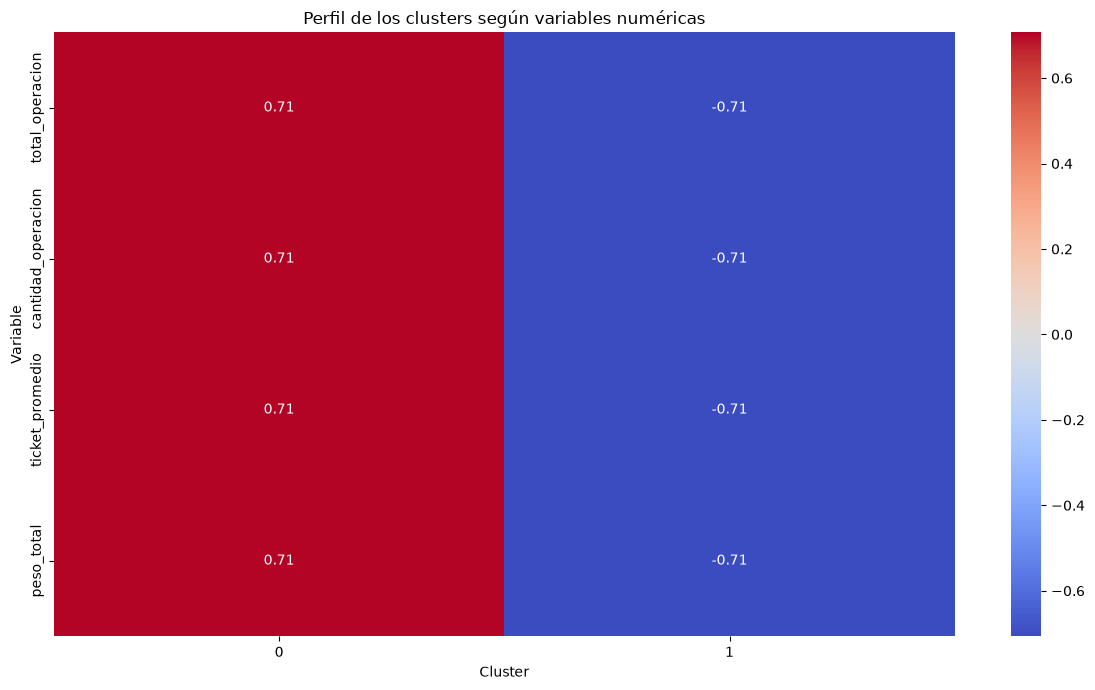

In [9]:
cluster_medianas = df_export.groupby("cluster")[numeric_cols].median()

cluster_medianas_norm = (
    cluster_medianas - cluster_medianas.mean()
) / cluster_medianas.std()

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_medianas_norm.T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.title("Perfil de los clusters según variables numéricas")
plt.tight_layout()
plt.show()

### 6.4 Observación

k=2 separa un cluster de **operaciones grandes** (302.479 filas, mediana total_operacion \$122.933) de uno de **operaciones pequeñas** (125.567 filas, mediana \$4.526) — estable en validación cruzada (media 0,2626, desviación estándar 0,0025), pero, igual que en import, una distinción binaria "altas vs. bajas" resulta poco interesante para caracterizar el negocio de exportación. Se explora a continuación **k=5** en busca de un perfil más granular.

## 7. Modelo B — k=5 (mayor granularidad)

Se repite el ajuste del modelo fijando k=5, para evaluar si una segmentación más fina produce clusters balanceados y con un perfil de negocio distinguible.

> **Corrección aplicada:** en la versión original de este notebook, la celda que fijaba `k=5` usaba por error la variable `K` (mayúscula) en lugar de `k`, por lo que el valor no se propagaba y hubo que fijar `n_clusters=5` manualmente en la celda de entrenamiento. Se corrige aquí usando `k = 5` de forma consistente con el resto del notebook.

In [ ]:
k = 5

> **Nota:** a diferencia del modelo k=2, este notebook no ejecutó una validación cruzada específica para k=5. Se recomienda como paso siguiente (ver sección de limitaciones) — la validación cruzada de k=5 sí se realizó en el notebook de importación y mostró buena estabilidad, pero no se replicó aquí.

### 7.1 Entrenamiento y perfil de los clusters

In [10]:
pipeline.set_params(
    kmeans__n_clusters=k
)

pipeline.fit(
    df_export[numeric_cols + categorical_cols]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['total_operacion','cantidad_operacion','ticket_promedio',..., 'rubro_empresa','pais','via_transporte']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automati

In [ ]:
df_export["cluster"] = pipeline.predict(
    df_export[numeric_cols + categorical_cols]
)

In [11]:
df_export["cluster"].value_counts().sort_index()

cluster
0     55850
1     79046
2    104234
3    156676
4     32240
Name: count, dtype: int64

In [12]:
df_export.groupby("cluster")[numeric_cols].median().T

cluster,0,1,2,3,4
total_operacion,882.985,383084.170000,16016.000000,81488.515,1291370.875
cantidad_operacion,1.000,19.000000,2.000000,2.000,4.000
ticket_promedio,457.405,19576.010625,5732.326666,39817.875,331720.405
peso_total,56.380,179349.965000,2215.000000,26400.000,392192.000


In [13]:
pd.options.display.float_format = '{:,.2f}'.format

df_export.groupby("cluster")[numeric_cols].mean().T

cluster,0,1,2,3,4
total_operacion,"1,477.58","1,569,458.51","25,635.78","117,180.43","9,844,457.25"
cantidad_operacion,2.99,45.81,4.15,2.68,5.57
ticket_promedio,825.39,"31,491.11","10,545.88","56,433.13","2,283,773.93"
peso_total,211.49,"763,664.68","5,853.06","54,029.34","7,527,029.31"


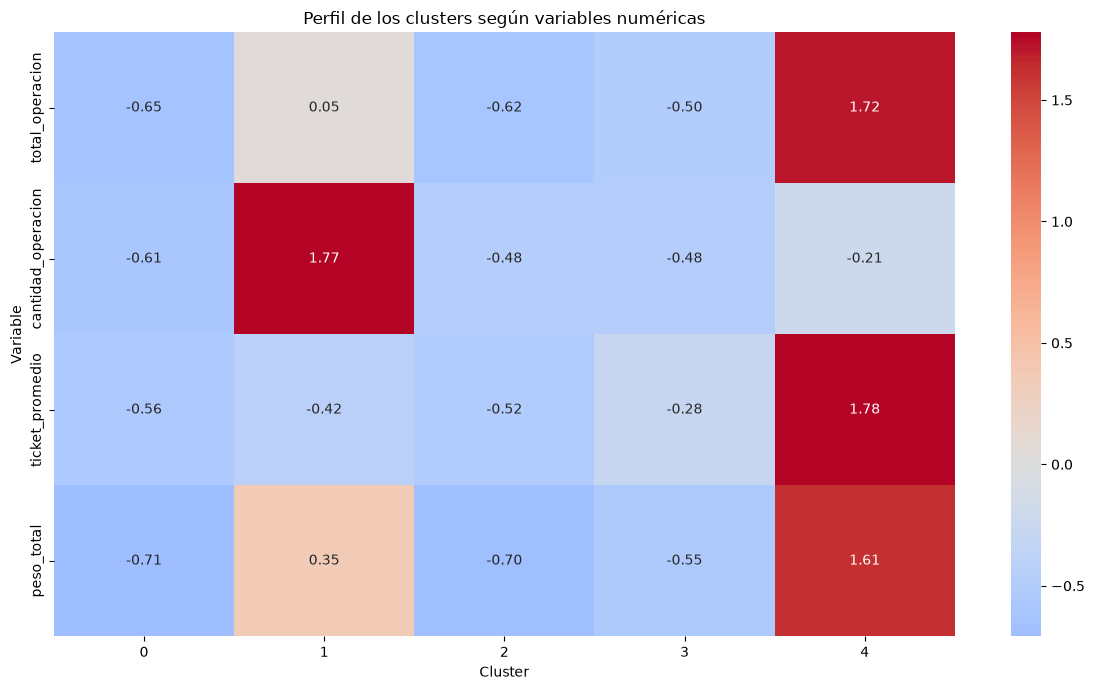

In [14]:
cluster_medianas = df_export.groupby("cluster")[numeric_cols].median()

cluster_medianas_norm = (
    cluster_medianas - cluster_medianas.mean()
) / cluster_medianas.std()

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_medianas_norm.T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.title("Perfil de los clusters según variables numéricas")
plt.tight_layout()
plt.show()

### 7.2 Visualización del perfil (radar)

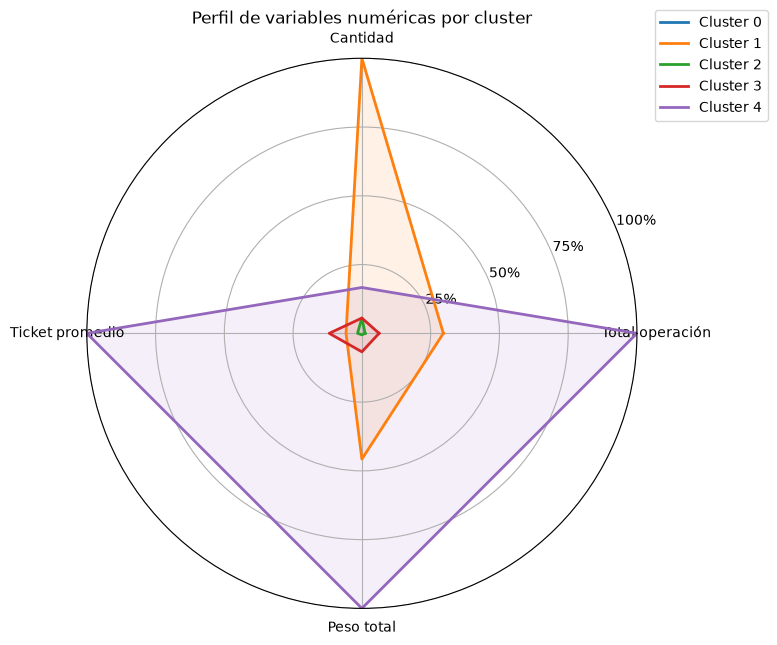

In [15]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

# Variables que queremos comparar
radar_cols = [
    "total_operacion",
    "cantidad_operacion",
    "ticket_promedio",
    "peso_total"
]

# Mediana por cluster
cluster_stats = (
    df_export
    .groupby("cluster")[radar_cols]
    .median()
)

# Normalización 0-1 entre clusters
scaler = MinMaxScaler()

cluster_norm = pd.DataFrame(
    scaler.fit_transform(cluster_stats),
    columns=radar_cols,
    index=cluster_stats.index
)

# Ángulos del radar
labels = [
    "Total operación",
    "Cantidad",
    "Ticket promedio",
    "Peso total"
]

angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

# Gráfico
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

for cluster in cluster_norm.index:

    values = cluster_norm.loc[cluster].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f"Cluster {cluster}"
    )

    ax.fill(
        angles,
        values,
        alpha=0.10
    )

# Ejes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)

ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["25%", "50%", "75%", "100%"])

ax.set_title(
    "Perfil de variables numéricas por cluster",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.25, 1.10)
)

plt.tight_layout()
plt.show()

### 7.3 Composición por rubro de empresa

In [ ]:
rubro_cluster = pd.crosstab(
    df_export["cluster"],
    df_export["rubro_empresa"],
    normalize="index"
) * 100

**Distribución completa de rubros dentro de cada cluster:**

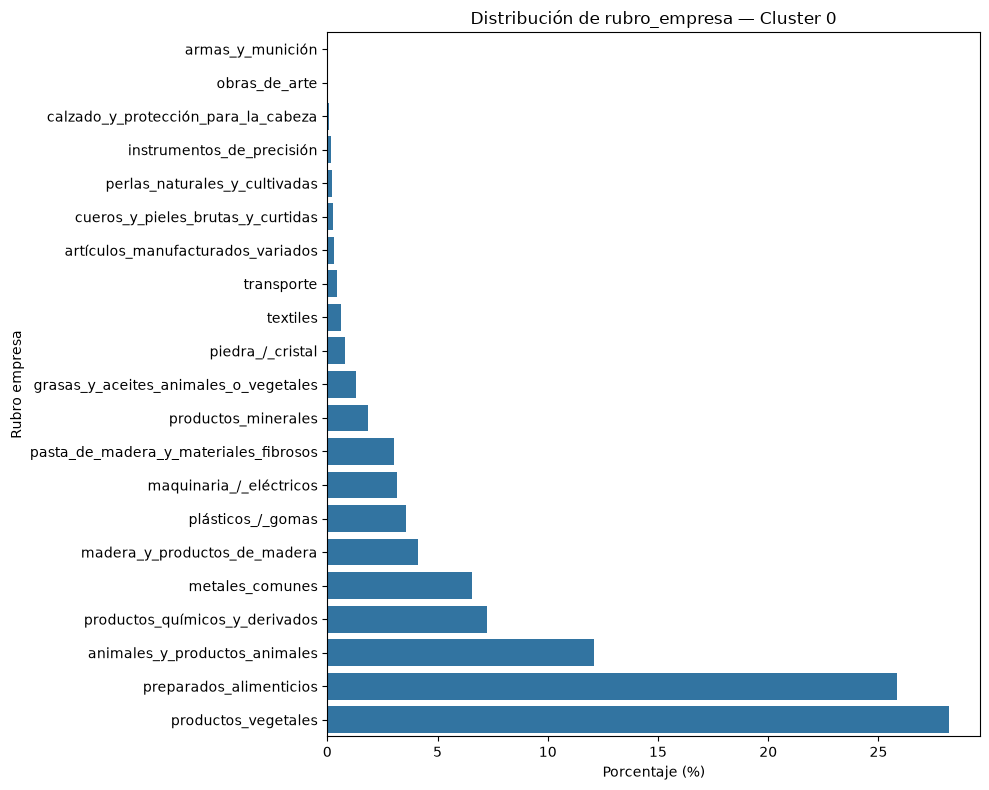

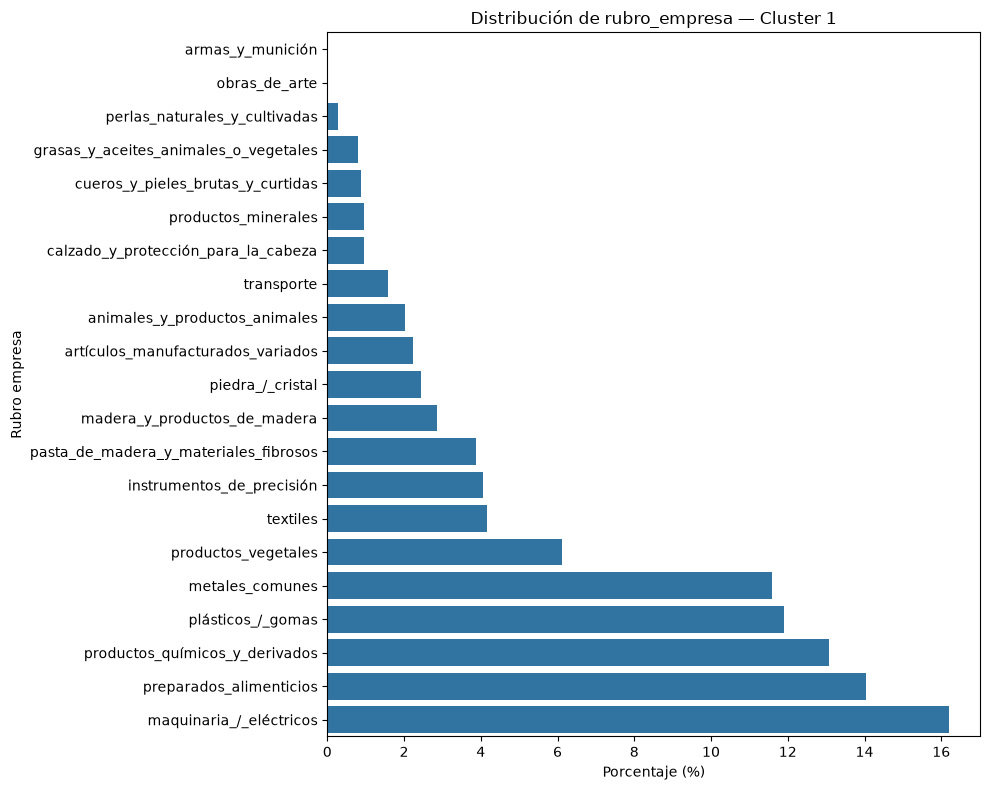

In [16]:
for cluster in sorted(rubro_cluster.index):

    datos = rubro_cluster.loc[cluster].sort_values(ascending=True)

    plt.figure(figsize=(10, 8))

    sns.barplot(
        x=datos.values,
        y=datos.index
    )

    plt.xlabel("Porcentaje (%)")
    plt.ylabel("Rubro empresa")
    plt.title(f"Distribución de rubro_empresa — Cluster {cluster}")

    plt.tight_layout()
    plt.show()

**Índice de sobre/sub-representación:** en vez de solo mirar el porcentaje absoluto de cada rubro (donde uno o dos rubros grandes dominan todos los clusters por igual), este índice compara la participación de cada rubro en cada cluster contra su participación promedio entre los 5 clusters. Un valor de 100 significa "participación típica"; por encima de 100, el rubro está sobre-representado en ese cluster (es distintivo de él); por debajo, sub-representado.

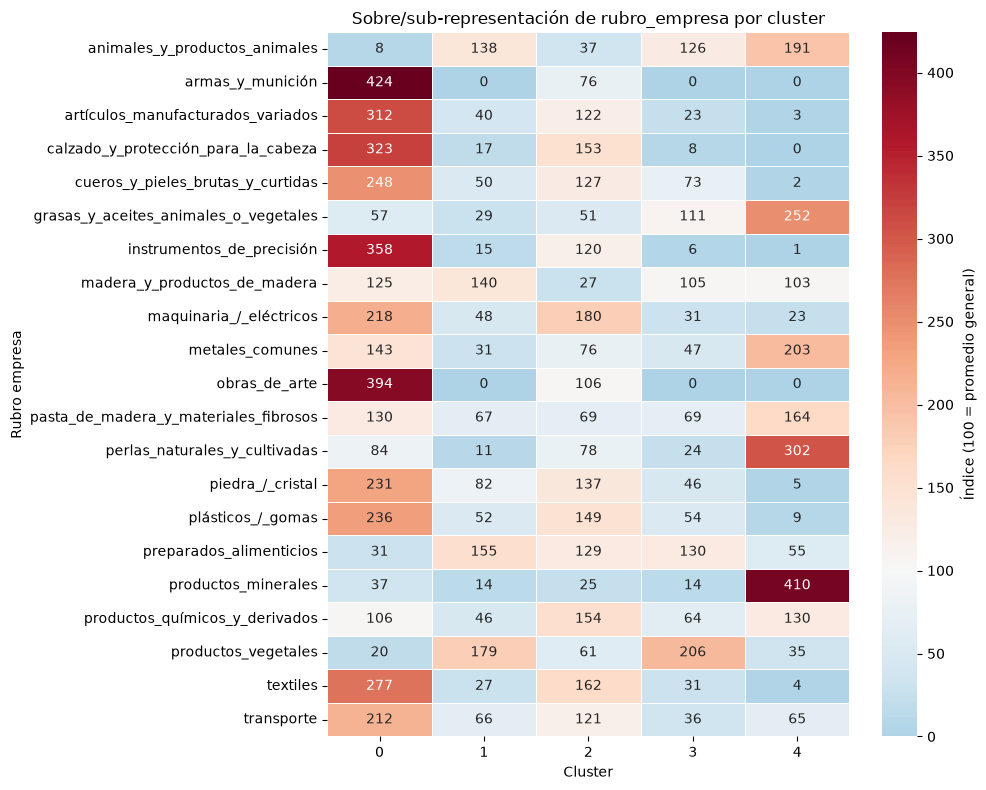

In [17]:
# Promedio general de cada rubro (sin distinguir cluster)
promedio_general = rubro_cluster.mean(axis=0)

# Índice: 100 = está en el promedio, >100 = sobre-representado en ese cluster, <100 = sub-representado
indice = (rubro_cluster / promedio_general) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(
    indice.T,
    annot=True,
    fmt=".0f",
    cmap="RdBu_r",   # rojo = sobre-representado, azul = sub-representado
    center=100,       # el punto neutro es 100 (ni sobre ni sub representado)
    cbar_kws={"label": "Índice (100 = promedio general)"},
    linewidths=0.5
)
plt.xlabel("Cluster")
plt.ylabel("Rubro empresa")
plt.title("Sobre/sub-representación de rubro_empresa por cluster")
plt.tight_layout()
plt.show()

**Comparación entre clusters — top 5 rubros de cada uno:**

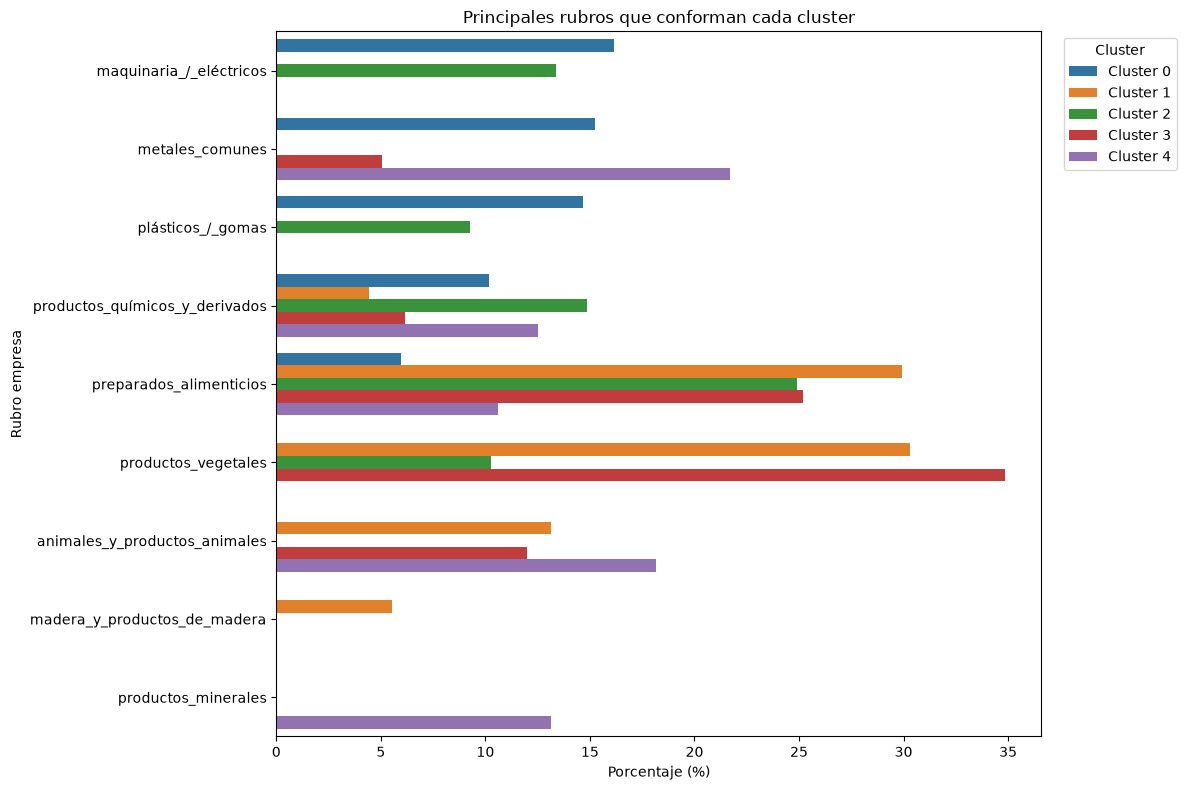

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 rubros de cada cluster
top_n = 5

datos = []

for cluster in rubro_cluster.index:

    top = (
        rubro_cluster.loc[cluster]
        .sort_values(ascending=False)
        .head(top_n)
    )

    for rubro, porcentaje in top.items():
        datos.append({
            "cluster": f"Cluster {cluster}",
            "rubro": rubro,
            "porcentaje": porcentaje
        })

df_top_rubros = pd.DataFrame(datos)


# Gráfico
plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_top_rubros,
    x="porcentaje",
    y="rubro",
    hue="cluster"
)

plt.xlabel("Porcentaje (%)")
plt.ylabel("Rubro empresa")
plt.title("Principales rubros que conforman cada cluster")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 7.4 Conclusiones — Modelo k=5

**Tamaños de cluster:**

| Cluster | Filas | % |
|---|---|---|
| 0 | 55.850 | 13,0% |
| 1 | 79.046 | 18,5% |
| 2 | 104.234 | 24,4% |
| 3 | 156.676 | 36,6% |
| 4 | 32.240 | 7,5% |

El reparto es más desigual que en import (allá iba de 15% a 25%; aquí va de 7,5% a 36,6%), pero ningún cluster es un residuo de outliers — el más chico (32.240 filas) sigue siendo un grupo perfectamente analizable.

**Perfil numérico (mediana):**

| Cluster | total_operacion | cantidad_operacion | ticket_promedio | peso_total | Perfil |
|---|---|---|---|---|---|
| 0 | 882,99 | 1 | 457,41 | 56,38 | Micro-operaciones |
| 2 | 16.016,00 | 2 | 5.732,33 | 2.215,00 | Pequeñas, bajo valor |
| 3 | 81.488,52 | 2 | 39.817,88 | 26.400,00 | Alto valor unitario, baja frecuencia |
| 1 | 383.084,17 | 19 | 19.576,01 | 179.349,97 | Alto volumen / bulk — la mayor frecuencia |
| 4 | 1.291.370,88 | 4 | 331.720,41 | 392.192,00 | Grandes operaciones |

El cluster 4 muestra la mayor dispersión interna de todo el análisis: su media de `total_operacion` (\$9.844.457) es **~7,6 veces** su mediana (\$1.291.371) — señal de que, dentro de este grupo relativamente pequeño (7,5% del total), conviven operaciones grandes con algunas verdaderamente descomunales.

**Composición por rubro (según el gráfico comparativo):**
- **Cluster 0** (micro-operaciones): maquinaria/eléctricos, metales comunes y plásticos/gomas — bienes manufacturados, sin presencia agrícola.
- **Cluster 1** (alto volumen): dominado por preparados alimenticios (~30%) y productos vegetales (~30%), con animales (~13%) y el único cluster con presencia de madera — perfil claramente **agroindustrial**.
- **Cluster 3** (alto valor unitario): productos vegetales alcanza aquí su participación más alta de toda la tabla (~35%) — posible indicio de fruta fresca de mayor valor, a diferencia del perfil más "bulk" del cluster 1.
- **Cluster 4** (grandes operaciones, mayor dispersión): metales comunes (~21,5%) y el único cluster con presencia de productos minerales (~13%) — perfil de **commodities pesados**.

> **Interpretación de negocio (hipótesis, no verificada directamente en los datos):** el patrón del cluster 4 —pocas operaciones (7,5%) pero de magnitud extrema y con metales/minerales como rubro distintivo— es consistente con la hipótesis de que corresponde en gran parte a **exportación minera (cobre)**, el principal producto de exportación de Chile: pocos embarques, pero cada uno de un cargamento de gran volumen. De forma análoga, los clusters 1 y 3 son consistentes con la **agroindustria y fruticultura de exportación**. Esta lectura es plausible y coherente con la estructura conocida de la economía chilena, pero no está confirmada por una variable del dataset que identifique el producto exacto.

> **Nota metodológica:** los porcentajes de rubro se leyeron del gráfico comparativo, no de una tabla exportada — son aproximados.

## 8. Modelo alternativo — K-Prototypes

Se aplica K-Prototypes como validación independiente del resultado de K-Means, por las mismas razones expuestas en el notebook de importación: evita la dilución del peso de las variables numéricas que puede introducir el one-hot encoding.

In [ ]:
import time
import pickle
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp

In [19]:
# --- Preparar los datos ---
# K-Prototypes no necesita OneHotEncoder para las categóricas,
# pero sí conviene escalar las numéricas para que no dominen la distancia

from sklearn.preprocessing import StandardScaler

df_model = df_export[numeric_cols + categorical_cols].copy()

# Escalar numéricas (mismo criterio que ya usabas: log + scale)
scaler = StandardScaler()
df_model[numeric_cols] = scaler.fit_transform(
    np.log1p(df_model[numeric_cols])
)

# Categóricas deben ir como string (kmodes lo requiere)
for col in categorical_cols:
    df_model[col] = df_model[col].astype(str)

X_mixed = df_model[numeric_cols + categorical_cols].values

# Índices de las columnas categóricas (posición, no nombre)
categorical_idx = [
    df_model.columns.get_loc(col) for col in categorical_cols
]

print("Índices categóricos:", categorical_idx)

Índices categóricos: [4, 5, 6]


In [ ]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_cat_ohe = ohe.fit_transform(df_model[categorical_cols])
X_num = df_model[numeric_cols].values
X_para_silhouette = sp.hstack([X_num, X_cat_ohe]).tocsr()

sample_size = 5000
rng = np.random.RandomState(42)
sil_indices = rng.choice(X_para_silhouette.shape[0], size=sample_size, replace=False)
X_sample_silhouette = X_para_silhouette[sil_indices]

### 8.1 Barrido de k (cost + silhouette)

In [20]:
k_values = range(2, 6)
resultados = []

for k in k_values:
    t0 = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] Empezando k={k}...")

    kproto = KPrototypes(
        n_clusters=k,
        init="Cao",
        n_init=2,
        max_iter=30,
        random_state=42,
        n_jobs=-1
    )

    labels = kproto.fit_predict(X_mixed, categorical=categorical_idx)
    score = silhouette_score(X_sample_silhouette, labels[sil_indices])

    resultado_k = {"k": k, "cost": kproto.cost_, "silhouette": score, "labels": labels}
    resultados.append(resultado_k)

    with open(f"resultado_k{k}.pkl", "wb") as f:
        pickle.dump(resultado_k, f)

    elapsed = time.time() - t0
    print(f"[{time.strftime('%H:%M:%S')}] k={k}: cost={kproto.cost_:.2f}, silhouette={score:.4f} ({elapsed/60:.1f} min)")

[01:05:19] Empezando k=2...
[01:10:42] k=2: cost=1398599.48, silhouette=0.2597 (5.4 min)
[01:10:42] Empezando k=3...
[01:19:16] k=3: cost=1106901.06, silhouette=0.1967 (8.6 min)
[01:19:16] Empezando k=4...
[01:31:46] k=4: cost=964998.60, silhouette=0.1424 (12.5 min)
[01:31:46] Empezando k=5...
[01:44:22] k=5: cost=875791.23, silhouette=0.1401 (12.6 min)


### 8.2 Selección del mejor k

> **Bug detectado y corregido:** la versión original de esta sección releía los resultados desde archivos `resultado_k{k}.pkl` guardados en disco (celda siguiente, ahora eliminada). Como el notebook de importación se ejecutó en el mismo directorio de trabajo y usa el mismo nombre de archivo, el `.pkl` de k=2 fue sobrescrito — el `resumen` original mostraba para k=2 un cost de 5.035.602 y un silhouette de 0,2366, que en realidad son los valores de **importación**, no de export. Esto provocó además un `ValueError` al intentar asignar los labels (de 1.572.022 filas, tamaño de import) al dataframe de export (428.046 filas).
>
> Se corrige usando directamente los resultados **en memoria** de la celda anterior (`resultados`), sin pasar por disco — evitando la colisión.

In [ ]:
resumen = pd.DataFrame([
    {"k": r["k"], "cost": r["cost"], "silhouette": r["silhouette"]}
    for r in resultados
])
print(resumen)

mejor = resumen.loc[resumen["silhouette"].idxmax()]
k_final = int(mejor["k"])
print(f"Mejor k según silhouette: {k_final} (silhouette={mejor['silhouette']:.4f})")

resultado_final = next(r for r in resultados if r["k"] == k_final)
labels_final = resultado_final["labels"]

df_export["cluster_kproto"] = labels_final

### 8.3 Perfil de los clusters (K-Prototypes)

> **Pendiente de re-ejecución:** como consecuencia del bug anterior, esta sección nunca llegó a correr exitosamente en el notebook original (la asignación de `cluster_kproto` fallaba antes de llegar aquí). El código queda corregido y listo para ejecutar, pero los resultados (perfil numérico y distribución por rubro/país/vía) deben regenerarse corriendo el notebook completo con el dataset real — no se incluyen valores en esta versión para evitar reportar cifras no verificadas.

In [ ]:
perfil_medianas = df_export.groupby("cluster_kproto")[numeric_cols].median()
perfil_medias = df_export.groupby("cluster_kproto")[numeric_cols].mean()
tamanos = df_export["cluster_kproto"].value_counts().sort_index()

perfil_medianas.to_csv("kproto_perfil_medianas.csv")
perfil_medias.to_csv("kproto_perfil_medias.csv")
tamanos.to_csv("kproto_tamanos_cluster.csv")

print(tamanos)
print(perfil_medianas)
print(perfil_medias)

In [ ]:
for col in categorical_cols:
    crosstab = pd.crosstab(
        df_export["cluster_kproto"],
        df_export[col],
        normalize="index"
    ) * 100
    crosstab.to_csv(f"kproto_distribucion_{col}.csv")

    for cluster in sorted(crosstab.index):
        top5 = crosstab.loc[cluster].sort_values(ascending=False).head(5)
        print(f"Cluster {cluster} - {col}: {dict(top5.round(1))}")

### 8.4 Conclusiones — K-Prototypes vs. K-Means

Aun sin el perfil detallado de clusters, el barrido de k (sección 8.1) por sí solo ya es suficiente para la comparación principal: K-Prototypes obtiene su mejor silhouette en **k=2 (0,2597)**, prácticamente idéntico al **0,2661** de K-Means con el mismo k. Esta coincidencia entre dos algoritmos con mecanismos de distancia distintos confirma, igual que en import, que el techo de separación (~0,26) es una propiedad intrínseca de los datos de exportación, no una limitación del algoritmo o del encoding.

El perfil de negocio detallado por rubro/país/vía queda pendiente de regenerar (ver 8.3) una vez corregido el bug de origen.

## 9. Conclusiones generales del proyecto

**Sobre la selección de k:** tanto K-Means como K-Prototypes coinciden en que k=2 es la configuración con mayor separación estadística (silhouette ~0,26–0,27), superior incluso al mejor resultado obtenido en import (~0,24). Sin embargo, k=5 —con un silhouette considerablemente menor (0,1424, una caída de ~46% respecto a k=2)— produce una segmentación con una narrativa de negocio mucho más clara: separa las operaciones en perfiles reconocibles de magnitud, frecuencia y rubro, incluyendo un cluster de "grandes operaciones" con un perfil de rubro consistente con la hipótesis de exportación minera.

**Recomendación:** al igual que en import, la elección entre k=2 y k=5 depende del uso previsto — k=2 para un filtro simple y estadísticamente sólido; k=5 para una segmentación accionable a nivel de negocio.

**Comparación import vs. export:** export logra mejor separación estadística que import en ambas configuraciones de k, y su segmentación en k=5 traza una historia sectorial más nítida (agroindustria, fruticultura, minería) que import, cuyos clusters se explican más por el tipo de compra (frecuencia, tamaño) que por sector económico — coherente con que Chile exporta de forma concentrada en pocos sectores estratégicos, pero importa de forma diversa y fragmentada.

## 10. Limitaciones y próximos pasos

- **Barrido de k limitado a 2–5:** a diferencia de import (2–9), no se exploraron valores mayores a 5. Recomendable extenderlo para confirmar que no existe un óptimo adicional.
- **Sin validación cruzada para k=5:** el modelo k=2 sí fue validado con 5-fold CV; el modelo k=5 no. Es el paso más directo a completar antes de reportar k=5 como resultado final con la misma confianza que k=2.
- **Perfil de K-Prototypes pendiente de regenerar:** el bug de colisión de archivos `.pkl` impidió completar la caracterización detallada por ese algoritmo — el código ya está corregido, solo falta volver a ejecutarlo con los datos reales.
- **Composición por rubro solo aproximada para k=5:** leída del gráfico comparativo, no de una tabla exportada.
- **Hipótesis sectoriales (minería, agroindustria) no verificadas directamente:** el dataset no identifica el producto exacto (ej. cobre, uva, celulosa) — cruzar con país de destino y/o partida arancelaria completa permitiría confirmar o refutar estas lecturas.
- **Recomendación transversal:** aplicar a import el mismo índice de sobre/sub-representación por rubro usado aquí (sección 7.3) para una comparación más rigurosa entre ambos flujos de comercio.